# 1.3 — Toolbox shakedown 🚀 Builder

**Parte 1.** Herramientas instaladas: Python 3.14, JupyterLab, NetworkX, y Claude Code como agente de terminal. Este notebook lo construyó el agente a partir del enunciado; las verificaciones manuales están marcadas.

## Parte 2 — Karate club: cargar, dibujar, reportar

nodos:   34
aristas: 78
5 nodos de mayor grado: [(33, 17), (0, 16), (32, 12), (2, 10), (1, 9)]


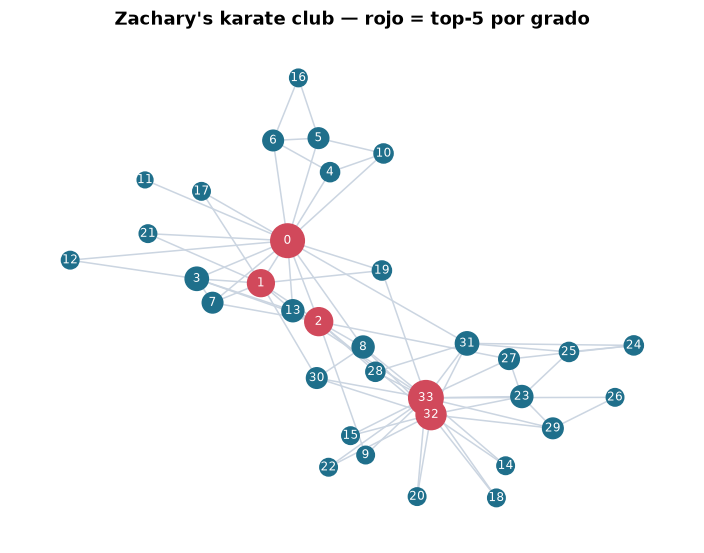

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import sgi
sgi.set_style()

G = nx.karate_club_graph()
print("nodos:  ", G.number_of_nodes())
print("aristas:", G.number_of_edges())
top5 = sorted(G.degree(), key=lambda x: -x[1])[:5]
print("5 nodos de mayor grado:", top5)

fig, ax = plt.subplots(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)
nx.draw_networkx(G, pos, ax=ax, node_color=["#d1495b" if n in dict(top5) else "#1f6f8b" for n in G],
                 node_size=[80 + 25 * d for _, d in G.degree()], font_size=8, font_color="white",
                 edge_color="#cbd5e1")
ax.set_title("Zachary's karate club — rojo = top-5 por grado"); ax.axis("off"); plt.show()

## Parte 3 — Verificar una afirmación a mano

Afirmación del agente: *el nodo 33 tiene grado 17*. Para verificarla sin confiar en `G.degree`, listamos sus vecinos y los contamos uno por uno — y comparamos contra la lista de aristas cruda del dataset.

In [2]:
vecinos = sorted(G.neighbors(33))
print("vecinos de 33:", vecinos)
print("contados a mano:", len(vecinos))
# segunda vía independiente: contar en la lista cruda de aristas cuántas tocan al 33
crudo = sum(1 for u, v in G.edges() if 33 in (u, v))
print("aristas crudas que tocan al 33:", crudo)
assert len(vecinos) == crudo == G.degree(33)

vecinos de 33: [8, 9, 13, 14, 15, 18, 19, 20, 22, 23, 26, 27, 28, 29, 30, 31, 32]
contados a mano: 17
aristas crudas que tocan al 33: 17


**Evaluación del agente (tres frases, escribir a mano):**

_TODO — ¿qué hizo bien, qué tuviste que corregir, qué no le confiarías sin verificar?_

## Parte 4 — Reconstruir el explorable de la matriz de adyacencia

Una función que toma una matriz *n×n*, la convierte en un grafo dirigido, lo dibuja y reporta grados; luego la simetriza y la convierte a no dirigido. Después la probamos con pesos, nodos aislados y self-loops.

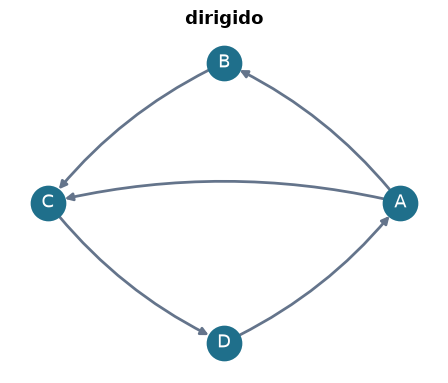

in-degree:  {'A': 1, 'B': 1, 'C': 2, 'D': 1}
out-degree: {'A': 2, 'B': 1, 'C': 1, 'D': 1}


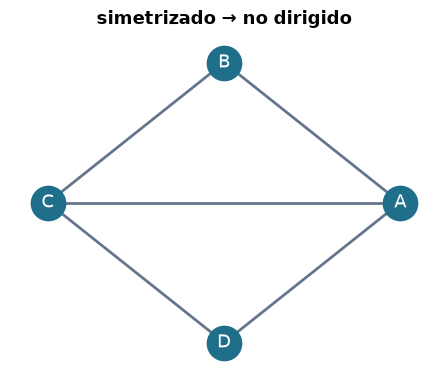

degree: {'A': 3, 'B': 2, 'C': 3, 'D': 2}

matriz simetrizada:
 [[0 1 1 1]
 [1 0 1 0]
 [1 1 0 1]
 [1 0 1 0]]


In [3]:
import numpy as np

def desde_matriz(A, dirigido=True, etiquetas=None, titulo=""):
    """Matriz de adyacencia -> grafo. A[i, j] != 0 significa arista i -> j (peso = A[i, j])."""
    A = np.asarray(A)
    assert A.ndim == 2 and A.shape[0] == A.shape[1], "la matriz debe ser cuadrada"
    tipo = nx.DiGraph if dirigido else nx.Graph
    G = nx.from_numpy_array(A, create_using=tipo)
    if etiquetas:
        G = nx.relabel_nodes(G, dict(enumerate(etiquetas)))
    fig, ax = plt.subplots(figsize=(5, 4))
    pos = nx.circular_layout(G)
    pesos = [d.get("weight", 1) for _, _, d in G.edges(data=True)]
    extra = {"connectionstyle": "arc3,rad=0.12"} if dirigido else {}   # solo aplica a flechas
    nx.draw_networkx(G, pos, ax=ax, node_color="#1f6f8b", font_color="white", node_size=500,
                     width=[0.6 + 1.2 * w for w in pesos], edge_color="#64748b", arrows=dirigido, **extra)
    ax.set_title(titulo); ax.axis("off"); plt.show()
    if dirigido:
        print("in-degree: ", dict(G.in_degree()))
        print("out-degree:", dict(G.out_degree()))
    else:
        print("degree:", dict(G.degree()))
    return G

def simetrizar(A):
    """A_sym[i,j] = 1 si hay arista en cualquiera de las dos direcciones."""
    A = np.asarray(A)
    return ((A + A.T) > 0).astype(int)

A = np.array([[0, 1, 1, 0],
              [0, 0, 1, 0],
              [0, 0, 0, 1],
              [1, 0, 0, 0]])
Gd = desde_matriz(A, dirigido=True, etiquetas=list("ABCD"), titulo="dirigido")
Gu = desde_matriz(simetrizar(A), dirigido=False, etiquetas=list("ABCD"), titulo="simetrizado → no dirigido")
print("\nmatriz simetrizada:\n", simetrizar(A))

### Pruebas: pesos, nodos aislados, self-loops

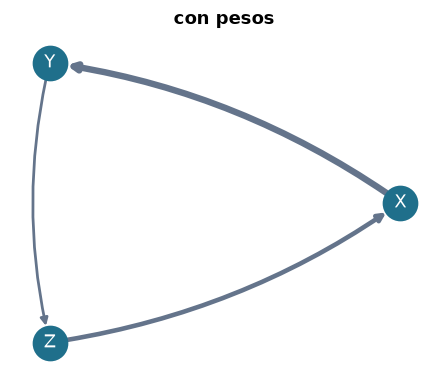

in-degree:  {'X': 1, 'Y': 1, 'Z': 1}
out-degree: {'X': 1, 'Y': 1, 'Z': 1}
pesos: {('X', 'Y'): 3, ('Y', 'Z'): 1, ('Z', 'X'): 2}


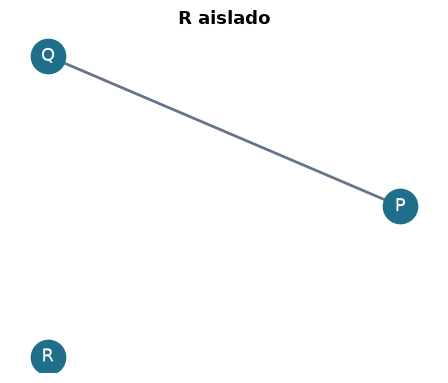

degree: {'P': 1, 'Q': 1, 'R': 0}
R está en el grafo: True | grado de R: 0


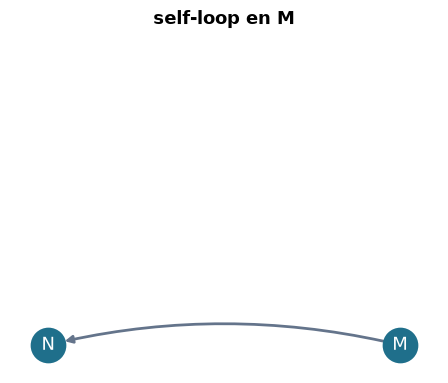

in-degree:  {'M': 1, 'N': 1}
out-degree: {'M': 2, 'N': 0}
self-loops: [('M', 'M')]


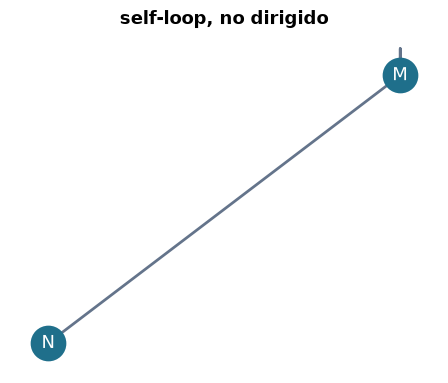

degree: {'M': 3, 'N': 1}
grado de M no dirigido: 3 ← un self-loop cuenta 2 en no dirigido


In [4]:
# pesos: la matriz deja de ser 0/1
W = np.array([[0, 3, 0], [0, 0, 1], [2, 0, 0]])
Gw = desde_matriz(W, dirigido=True, etiquetas=list("XYZ"), titulo="con pesos")
print("pesos:", nx.get_edge_attributes(Gw, "weight"))

# nodo aislado: fila y columna de ceros — ¿sobrevive?
I = np.array([[0, 1, 0], [1, 0, 0], [0, 0, 0]])
Gi = desde_matriz(I, dirigido=False, etiquetas=list("PQR"), titulo="R aislado")
print("R está en el grafo:", "R" in Gi, "| grado de R:", Gi.degree("R"))

# self-loop: 1 en la diagonal — ¿cómo cuenta en el grado?
S = np.array([[1, 1], [0, 0]])
Gs = desde_matriz(S, dirigido=True, etiquetas=list("MN"), titulo="self-loop en M")
print("self-loops:", list(nx.selfloop_edges(Gs)))
Gs_u = desde_matriz(simetrizar(S), dirigido=False, etiquetas=list("MN"), titulo="self-loop, no dirigido")
print("grado de M no dirigido:", Gs_u.degree("M"), "← un self-loop cuenta 2 en no dirigido")

**Qué observamos (escribir a mano):**

_TODO — ¿qué pasa con el aislado al construir desde la matriz vs desde una lista de aristas? ¿Cómo cuenta un self-loop en el grado dirigido vs no dirigido?_